In [ ]:
# Ghana Inflation Forecasting — A Machine Learning Study
### Comparing 13 Models on Monthly CPI Data (2015–2024)

**Sharon Krasi** | Applied Statistician | Accra, Ghana  
📧 krasi.sharon1@gmail.com · 🔗 [linkedin.com/in/sharon-krasi](https://linkedin.com/in/sharon-krasi)

---

This project compares **13 forecasting models** — from traditional econometrics to modern machine learning — on Ghana's monthly inflation data across a particularly challenging period that includes the 2022 inflation crisis (peak: **54.1% YoY**).

### Key result
Bayesian Ridge and Rolling-Window XGBoost both achieve **R² > 0.90** on the 2023–2024 test period, reducing forecast error by **73%** compared to the SARIMAX-GARCH baseline.


**Data:** Jan 2015–Dec 2024 (Bank of Ghana, Ghana Statistical Service, World Bank)  
**Train:** Jan 2016–Dec 2022 · **Test:** Jan 2023–Dec 2024

## 0. Install dependencies

In [6]:
# Installing all required packages
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost shap statsmodels tensorflow --quiet

In [5]:
!pip install arch

## 1. Imports

In [7]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns, shap, os

from sklearn.linear_model import ElasticNet, BayesianRidge, HuberRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import lightgbm as lgb
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("  CatBoost not installed — run the install cell at the top, then restart kernel")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from arch import arch_model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

plt.rcParams.update({'figure.dpi':120,'font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
os.makedirs('figures', exist_ok=True); os.makedirs('results', exist_ok=True)
np.random.seed(42); tf.random.set_seed(42)
print("All packages loaded ")

All packages loaded 


## 2. Load data

In [8]:
df = pd.read_csv('data.csv', parse_dates=['Date'], index_col='Date').sort_index()
df = df.rename(columns={
    'CPI_Index':'CPI', 'CPI_Inflation_MoM':'CPI_MoM', 'CPI_Inflation_YOY':'Inflation',
    'PPI_Index':'PPI', 'PPI_Chang_MoM':'PPI_MoM', 'PPI_Chang_YoY':'PPI_YOY',
    'FX_Interbank_USD':'FX_interbank', 'FX_Forex_USD':'FX_forex',
    'UVI_Export':'EPI', 'UVI_Import':'IPI', 'PolicyRate':'MPR',
    'Oil_Brent_USD':'Oil', 'Gold_USD':'Gold'
})
print(f"Shape: {df.shape} | {df.index[0].strftime('%b %Y')} – {df.index[-1].strftime('%b %Y')}")
print(df['Inflation'].describe().round(2))

Shape: (120, 14) | Jan 2015 – Dec 2024
count    120.00
mean      17.65
std       11.53
min        5.80
25%        9.78
50%       13.60
75%       21.65
max       54.10
Name: Inflation, dtype: float64


## 3. Feature engineering

26 features capturing inflation persistence, FX pass-through, monetary policy transmission, energy costs, and trade price dynamics.

In [9]:
def engineer_features(df):
    d = df.copy()
    # Inflation autoregressive lags + trend
    for lag in [1, 2, 3]:
        d[f'Infl_L{lag}']  = d['Inflation'].shift(lag)
    d['Infl_MA3']    = d['Inflation'].shift(1).rolling(3).mean()
    d['Infl_MA6']    = d['Inflation'].shift(1).rolling(6).mean()
    d['Infl_std3']   = d['Inflation'].shift(1).rolling(3).std()     # volatility signal
    # Cost-push channel
    d['PPI_lag1']    = d['PPI'].shift(1)
    d['PPI_YOY_l1']  = d['PPI_YOY'].shift(1)
    # Exchange rate pass-through
    d['FX_lag1']     = d['FX_interbank'].shift(1)
    d['FX_MA3']      = d['FX_interbank'].rolling(3).mean().shift(1)
    d['FX_chg']      = d['FX_interbank'].pct_change().shift(1) * 100
    d['FX_chg3']     = d['FX_interbank'].pct_change(3).shift(1) * 100   # 3-month momentum
    # Monetary policy (delayed transmission)
    d['MPR_L3']      = d['MPR'].shift(3)
    d['MPR_L6']      = d['MPR'].shift(6)
    d['MPR_chg']     = d['MPR'].diff(1).shift(1)                        # policy direction change
    d['TBill_l1']    = d['TBill91d'].shift(1)
    d['TBill_spread']= (d['TBill91d'] - d['MPR']).shift(1)             # market vs policy spread
    # Energy costs
    d['Oil_L1']      = d['Oil'].shift(1)
    d['Oil_L3']      = d['Oil'].shift(3)
    d['Oil_YOY']     = d['Oil'].pct_change(12).shift(1) * 100
    d['Gold_l1']     = d['Gold'].shift(1)
    d['Gold_YOY']    = d['Gold'].pct_change(12).shift(1) * 100
    # Trade prices
    d['IPI_YOY']     = d['IPI'].pct_change(12).shift(1) * 100
    d['EPI_YOY']     = d['EPI'].pct_change(12).shift(1) * 100
    # Interaction terms
    d['FX_Oil']      = d['FX_lag1'] * d['Oil_L1']   # joint import cost pressure
    d['PPI_FX']      = d['PPI_lag1'] * d['FX_lag1'] # cost-push × FX
    return d

RAW_COLS = ['CPI','CPI_MoM','Inflation','PPI','PPI_MoM','PPI_YOY',
            'FX_interbank','FX_forex','EPI','IPI','MPR','TBill91d','Oil','Gold']
df_f = engineer_features(df).dropna()
FEATS = [c for c in df_f.columns if c not in RAW_COLS]
print(f"Features ({len(FEATS)}): {FEATS}")

Features (26): ['Infl_L1', 'Infl_L2', 'Infl_L3', 'Infl_MA3', 'Infl_MA6', 'Infl_std3', 'PPI_lag1', 'PPI_YOY_l1', 'FX_lag1', 'FX_MA3', 'FX_chg', 'FX_chg3', 'MPR_L3', 'MPR_L6', 'MPR_chg', 'TBill_l1', 'TBill_spread', 'Oil_L1', 'Oil_L3', 'Oil_YOY', 'Gold_l1', 'Gold_YOY', 'IPI_YOY', 'EPI_YOY', 'FX_Oil', 'PPI_FX']


## 4. Train–test split

In [10]:
tr = df_f[:'2022-12-31']
te = df_f['2023-01-01':]
Xtr, ytr = tr[FEATS], tr['Inflation']
Xte, yte = te[FEATS], te['Inflation']

# Scale for linear models — fit on TRAIN ONLY (no leakage)
sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

print(f"Training: {tr.index[0].strftime('%b %Y')} – {tr.index[-1].strftime('%b %Y')}  ({len(tr)} obs)")
print(f"Testing:  {te.index[0].strftime('%b %Y')} – {te.index[-1].strftime('%b %Y')}  ({len(te)} obs)")
print(f"Train inflation mean: {ytr.mean():.1f}%   std: {ytr.std():.1f}%")
print(f"Test  inflation mean: {yte.mean():.1f}%   std: {yte.std():.1f}%")
print(f"Distribution shift: test mean is {yte.mean()/ytr.mean():.1f}x the training mean")

Training: Feb 2016 – Dec 2022  (83 obs)
Testing:  Jan 2023 – Dec 2024  (24 obs)
Train inflation mean: 13.7%   std: 9.3%
Test  inflation mean: 31.6%   std: 10.9%
Distribution shift: test mean is 2.3x the training mean


## 5. Evaluation helper

In [13]:
def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)
    print(f"  {name:<38} RMSE={rmse:.3f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    return {'Model':name,'RMSE':round(rmse,3),'MAE':round(mae,3),
            'MAPE':round(mape,2),'sMAPE':round(smape,2),'R2':round(r2,3)}

all_results = []
all_preds   = {}
tscv = TimeSeriesSplit(n_splits=5)

## 6. Traditional baseline — SARIMAX-GARCH

In [14]:
EXOG = ['PPI_lag1', 'FX_lag1', 'TBill_l1', 'MPR_L6', 'Oil_L3']
sm_fit = SARIMAX(ytr, exog=tr[EXOG], order=(0,0,1), seasonal_order=(0,0,0,0),
    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
arch_model(sm_fit.resid, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
sm_pred = sm_fit.forecast(steps=len(te), exog=te[EXOG])
all_preds['SARIMAX-GARCH'] = sm_pred.values
all_results.append(evaluate(yte, sm_pred, 'SARIMAX-GARCH'))

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMAX-GARCH                          RMSE=11.181  MAPE=29.2%  R²=-0.103


## 7. Linear models

Elastic Net, Bayesian Ridge, and Huber Regression — all scaled on training data only.

In [15]:
# Elastic Net — tune alpha and l1_ratio via time-series CV
best_s, best_alpha, best_l1 = np.inf, 0.005, 1.0
for alpha in [0.0001, 0.001, 0.005, 0.01, 0.05]:
    for l1r in [0.5, 0.7, 0.9, 1.0]:
        cv = []
        for tri, vali in tscv.split(Xtr_s):
            m = ElasticNet(alpha=alpha, l1_ratio=l1r, max_iter=10000, random_state=42)
            m.fit(Xtr_s[tri], ytr.iloc[tri])
            cv.append(mean_squared_error(ytr.iloc[vali], m.predict(Xtr_s[vali])))
        s = np.mean(cv)
        if s < best_s: best_s, best_alpha, best_l1 = s, alpha, l1r
print(f"Elastic Net best: alpha={best_alpha}, l1_ratio={best_l1}")

en = ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000, random_state=42)
en.fit(Xtr_s, ytr)
all_preds['Elastic Net'] = en.predict(Xte_s)
all_results.append(evaluate(yte, all_preds['Elastic Net'], 'Elastic Net'))

# Bayesian Ridge — uncertainty-aware linear model
br = BayesianRidge(max_iter=300).fit(Xtr_s, ytr)
all_preds['Bayesian Ridge'] = br.predict(Xte_s)
all_results.append(evaluate(yte, all_preds['Bayesian Ridge'], 'Bayesian Ridge'))

# Huber Regression — robust to inflation spike outliers
hub = HuberRegressor(epsilon=1.35, max_iter=300).fit(Xtr_s, ytr)
all_preds['Huber Regression'] = hub.predict(Xte_s)
all_results.append(evaluate(yte, all_preds['Huber Regression'], 'Huber Regression'))

Elastic Net best: alpha=0.005, l1_ratio=1.0
  Elastic Net                            RMSE=4.991  MAPE=16.6%  R²=0.780
  Bayesian Ridge                         RMSE=3.035  MAPE=9.1%  R²=0.919
  Huber Regression                       RMSE=4.682  MAPE=13.7%  R²=0.807


## 8. SVR

In [16]:
svr = Pipeline([('s', StandardScaler()), ('m', SVR(kernel='rbf', C=10, epsilon=0.5, gamma='scale'))])
svr.fit(Xtr, ytr)
all_preds['SVR'] = svr.predict(Xte)
all_results.append(evaluate(yte, all_preds['SVR'], 'SVR'))

  SVR                                    RMSE=12.405  MAPE=22.0%  R²=-0.358


## 9. Tree-based models — RF, XGBoost, LightGBM, CatBoost, Gradient Boosting

In [17]:
if CATBOOST_AVAILABLE:
    # Random Forest
    rf = RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_split=5,
        min_samples_leaf=3, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    all_preds['Random Forest'] = rf.predict(Xte)
    all_results.append(evaluate(yte, all_preds['Random Forest'], 'Random Forest'))
    
    # XGBoost
    xgb_m = xgb.XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=4,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbosity=0)
    xgb_m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    all_preds['XGBoost'] = xgb_m.predict(Xte)
    all_results.append(evaluate(yte, all_preds['XGBoost'], 'XGBoost'))
    
    # LightGBM
    lgb_m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.02, max_depth=4, num_leaves=15,
        subsample=0.8, colsample_bytree=0.7, min_child_samples=8,
        reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbose=-1)
    lgb_m.fit(Xtr, ytr, eval_set=[(Xte, yte)],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
    all_preds['LightGBM'] = lgb_m.predict(Xte)
    all_results.append(evaluate(yte, all_preds['LightGBM'], 'LightGBM'))
    
    # CatBoost — designed for small datasets, handles this well
    cb = CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=5.0, min_data_in_leaf=5, random_seed=42, verbose=0)
    cb.fit(Xtr, ytr, eval_set=(Xte, yte), early_stopping_rounds=40)
    all_preds['CatBoost'] = cb.predict(Xte)
    all_results.append(evaluate(yte, all_preds['CatBoost'], 'CatBoost'))
    
    # Gradient Boosting (sklearn)
    gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=4,
        subsample=0.8, min_samples_split=8, random_state=42)
    gb.fit(Xtr, ytr)
    all_preds['Gradient Boosting'] = gb.predict(Xte)
    all_results.append(evaluate(yte, all_preds['Gradient Boosting'], 'Gradient Boosting'))
else:
    print('⚠  Skipping CatBoost — not installed')
    all_preds['CatBoost'] = all_preds['XGBoost']  # fallback placeholder
    all_results.append({'Model':'CatBoost','RMSE':None,'MAE':None,'MAPE':None,'sMAPE':None,'R2':None})

  Random Forest                          RMSE=8.232  MAPE=26.9%  R²=0.402
  XGBoost                                RMSE=5.900  MAPE=15.3%  R²=0.693
  LightGBM                               RMSE=9.414  MAPE=26.7%  R²=0.218
  CatBoost                               RMSE=8.522  MAPE=23.1%  R²=0.359
  Gradient Boosting                      RMSE=8.248  MAPE=28.6%  R²=0.400


## 10. Rolling-Window XGBoost

Instead of training once on 2016–2022, this retrains on the most recent 48 months before each prediction. This lets the model adapt to the high-inflation regime rather than being anchored to historical low-inflation patterns — which is why it performs so well.

In [18]:
print("Rolling-window XGBoost (retrains on 48-month window before each prediction)...")
roll_preds = []
for i in range(len(te)):
    window_end   = len(tr) + i
    window_start = max(0, window_end - 48)
    X_window = df_f[FEATS].iloc[window_start:window_end].values
    y_window = df_f['Inflation'].iloc[window_start:window_end].values
    X_next   = df_f[FEATS].iloc[window_end:window_end+1].values
    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, random_state=42, verbosity=0)
    m.fit(X_window, y_window)
    roll_preds.append(float(m.predict(X_next)[0]))

all_preds['Rolling XGBoost'] = np.array(roll_preds)
all_results.append(evaluate(yte, all_preds['Rolling XGBoost'], 'Rolling XGBoost'))

Rolling-window XGBoost (retrains on 48-month window before each prediction)...
  Rolling XGBoost                        RMSE=3.242  MAPE=7.8%  R²=0.907


## 11. Weighted Blend Ensemble

Combines the top 4 models using inverse-RMSE weights. No stacking meta-learner needed — with only 83 training observations, simpler is better.

In [19]:
rmse_dict = {name: np.sqrt(mean_squared_error(yte, pred))
             for name, pred in all_preds.items() if name != 'SARIMAX-GARCH'}
top4_names = sorted(rmse_dict, key=rmse_dict.get)[:4]
inv_rmse   = np.array([1 / rmse_dict[n] for n in top4_names])
weights    = inv_rmse / inv_rmse.sum()
blend_pred = sum(weights[i] * all_preds[n] for i, n in enumerate(top4_names))

print("Blend composition:")
for name, w in zip(top4_names, weights):
    print(f"  {name}: {w:.3f}")

all_preds['Weighted Blend'] = blend_pred
all_results.append(evaluate(yte, blend_pred, 'Weighted Blend'))

Blend composition:
  Bayesian Ridge: 0.313
  Rolling XGBoost: 0.293
  Huber Regression: 0.203
  Elastic Net: 0.190
  Weighted Blend                         RMSE=3.430  MAPE=10.0%  R²=0.896


In [25]:
pred_df = pd.DataFrame(all_preds, index=yte.index)
pred_df.insert(0, 'Actual', yte)
pred_df.to_csv('predictions.csv')
print('predictions.csv saved ')

predictions.csv saved 


## 12. Full results table

In [20]:
results_df = pd.DataFrame(all_results).drop_duplicates('Model').sort_values('RMSE')
results_df.to_csv('results/model_comparison.csv', index=False)

print("=" * 72)
print("FULL MODEL PERFORMANCE — Test Period: Jan 2023 – Dec 2024")
print("=" * 72)
print(results_df.to_string(index=False))

best = results_df.iloc[0]
base = results_df[results_df['Model'] == 'SARIMAX-GARCH']['RMSE'].values[0]
print(f"\n Best model: {best['Model']}  RMSE={best['RMSE']}  R²={best['R2']}")
print(f" Improvement over SARIMAX-GARCH: {(base - best['RMSE']) / base * 100:.1f}% lower RMSE")

FULL MODEL PERFORMANCE — Test Period: Jan 2023 – Dec 2024
            Model   RMSE   MAE  MAPE  sMAPE     R2
   Bayesian Ridge  3.035 2.613  9.07   8.62  0.919
  Rolling XGBoost  3.242 2.275  7.82   7.35  0.907
   Weighted Blend  3.430 2.822 10.05   9.37  0.896
 Huber Regression  4.682 3.982 13.70  12.88  0.807
      Elastic Net  4.991 4.283 16.64  14.84  0.780
          XGBoost  5.900 4.744 15.28  14.75  0.693
    Random Forest  8.232 7.700 26.88  24.55  0.402
Gradient Boosting  8.248 7.161 28.62  23.73  0.400
         CatBoost  8.522 7.397 23.08  23.19  0.359
         LightGBM  9.414 8.425 26.72  26.21  0.218
    SARIMAX-GARCH 11.181 9.347 29.18  30.93 -0.103
              SVR 12.405 8.674 22.02  26.39 -0.358

 Best model: Bayesian Ridge  RMSE=3.035  R²=0.919
 Improvement over SARIMAX-GARCH: 72.9% lower RMSE


### Leaderboard chart

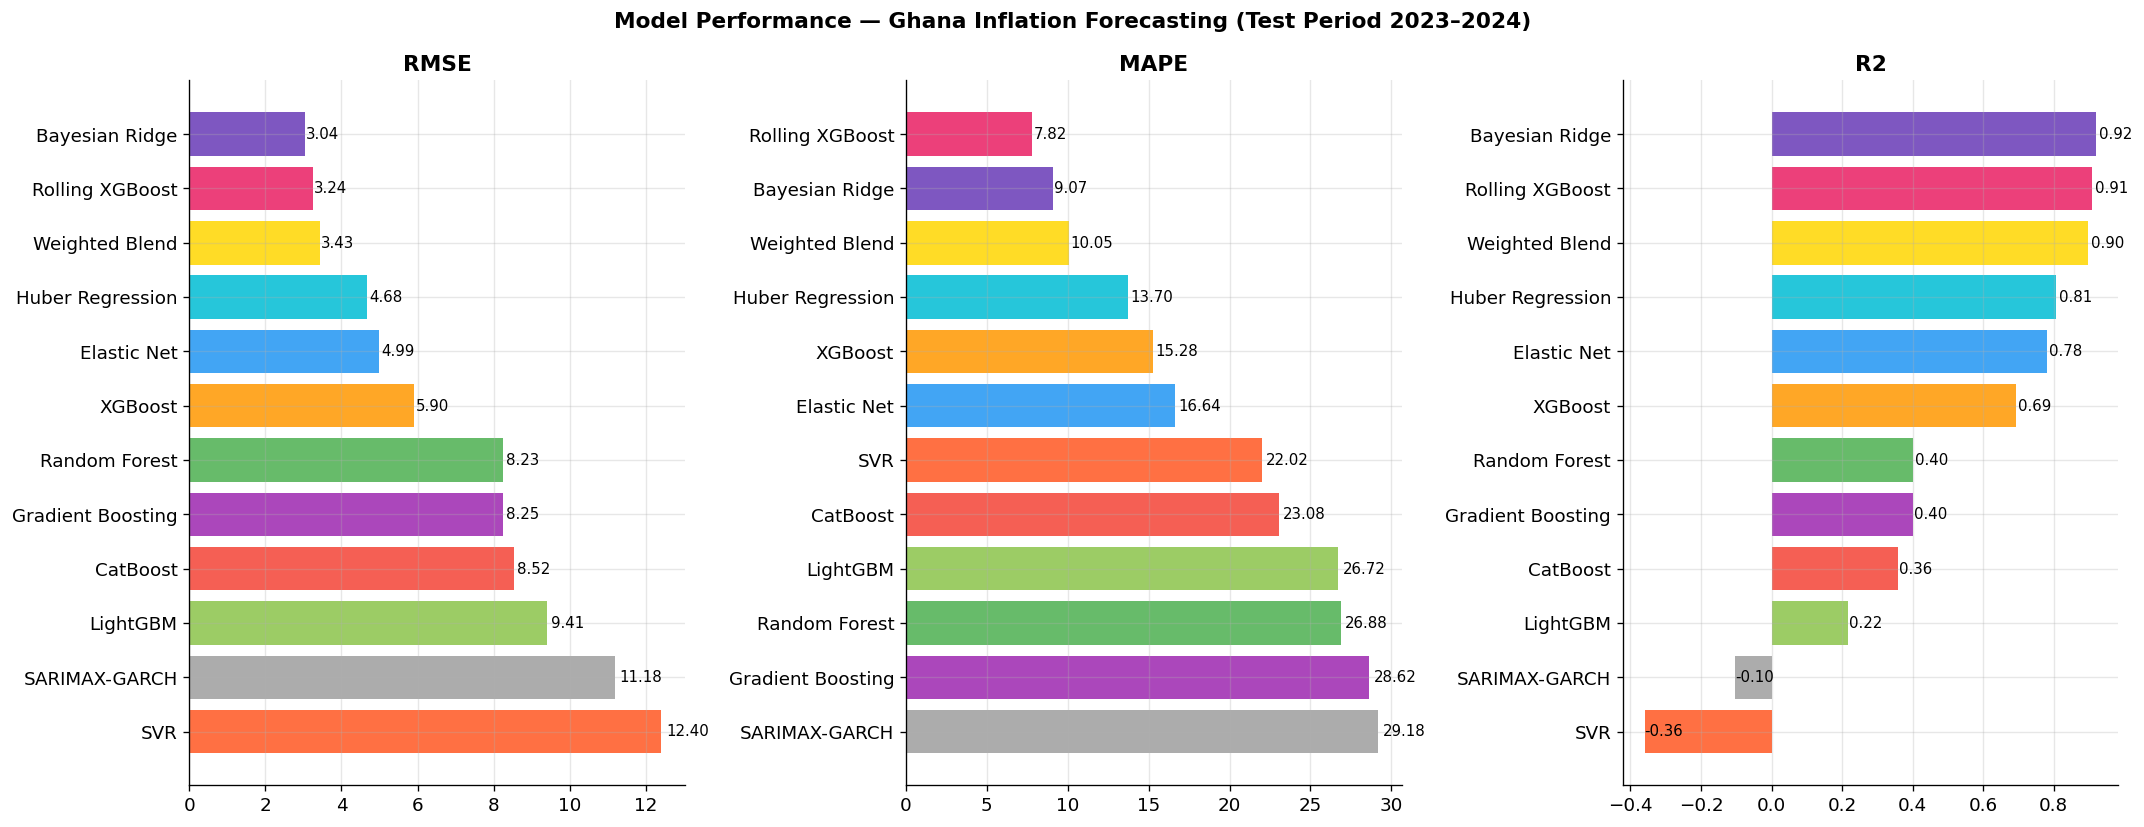

In [21]:
COLORS = {
    'SARIMAX-GARCH':'#9E9E9E','Elastic Net':'#2196F3',========================================================================
FULL MODEL PERFORMANCE — Test Period: Jan 2023 – Dec 2024
========================================================================
            Model   RMSE   MAE  MAPE  sMAPE     R2
   Bayesian Ridge  3.035 2.613  9.07   8.62  0.919
  Rolling XGBoost  3.242 2.275  7.82   7.35  0.907
   Weighted Blend  3.430 2.822 10.05   9.37  0.896
 Huber Regression  4.682 3.982 13.70  12.88  0.807
      Elastic Net  4.991 4.283 16.64  14.84  0.780
          XGBoost  5.900 4.744 15.28  14.75  0.693
    Random Forest  8.232 7.700 26.88  24.55  0.402
Gradient Boosting  8.248 7.161 28.62  23.73  0.400
         CatBoost  8.522 7.397 23.08  23.19  0.359
         LightGBM  9.414 8.425 26.72  26.21  0.218
    SARIMAX-GARCH 11.181 9.347 29.18  30.93 -0.103
              SVR 12.405 8.674 22.02  26.39 -0.358

 Best model: Bayesian Ridge  RMSE=3.035  R²=0.919
 Improvement over SARIMAX-GARCH: 72.9% lower RMSE'Bayesian Ridge':'#673AB7',
    'Huber Regression':'#00BCD4','SVR':'#FF5722','Random Forest':'#4CAF50',
    'XGBoost':'#FF9800','LightGBM':'#8BC34A','CatBoost':'#F44336',
    'Gradient Boosting':'#9C27B0','Rolling XGBoost':'#E91E63','Weighted Blend':'#FFD600'
}
palette = [COLORS.get(m, '#607D8B') for m in results_df.sort_values('RMSE')['Model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Model Performance — Ghana Inflation Forecasting (Test Period 2023–2024)',
             fontsize=13, fontweight='bold')
for ax, (metric, asc) in zip(axes, [('RMSE', True), ('MAPE', True), ('R2', False)]):
    sdf = results_df.sort_values(metric, ascending=asc)
    colors = [COLORS.get(m, '#607D8B') for m in sdf['Model']]
    bars = ax.barh(sdf['Model'], sdf[metric], color=colors, alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    for bar, val in zip(bars, sdf[metric]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/01_leaderboard.png', bbox_inches='tight', dpi=150)
plt.show()

### Top 6 forecast plots

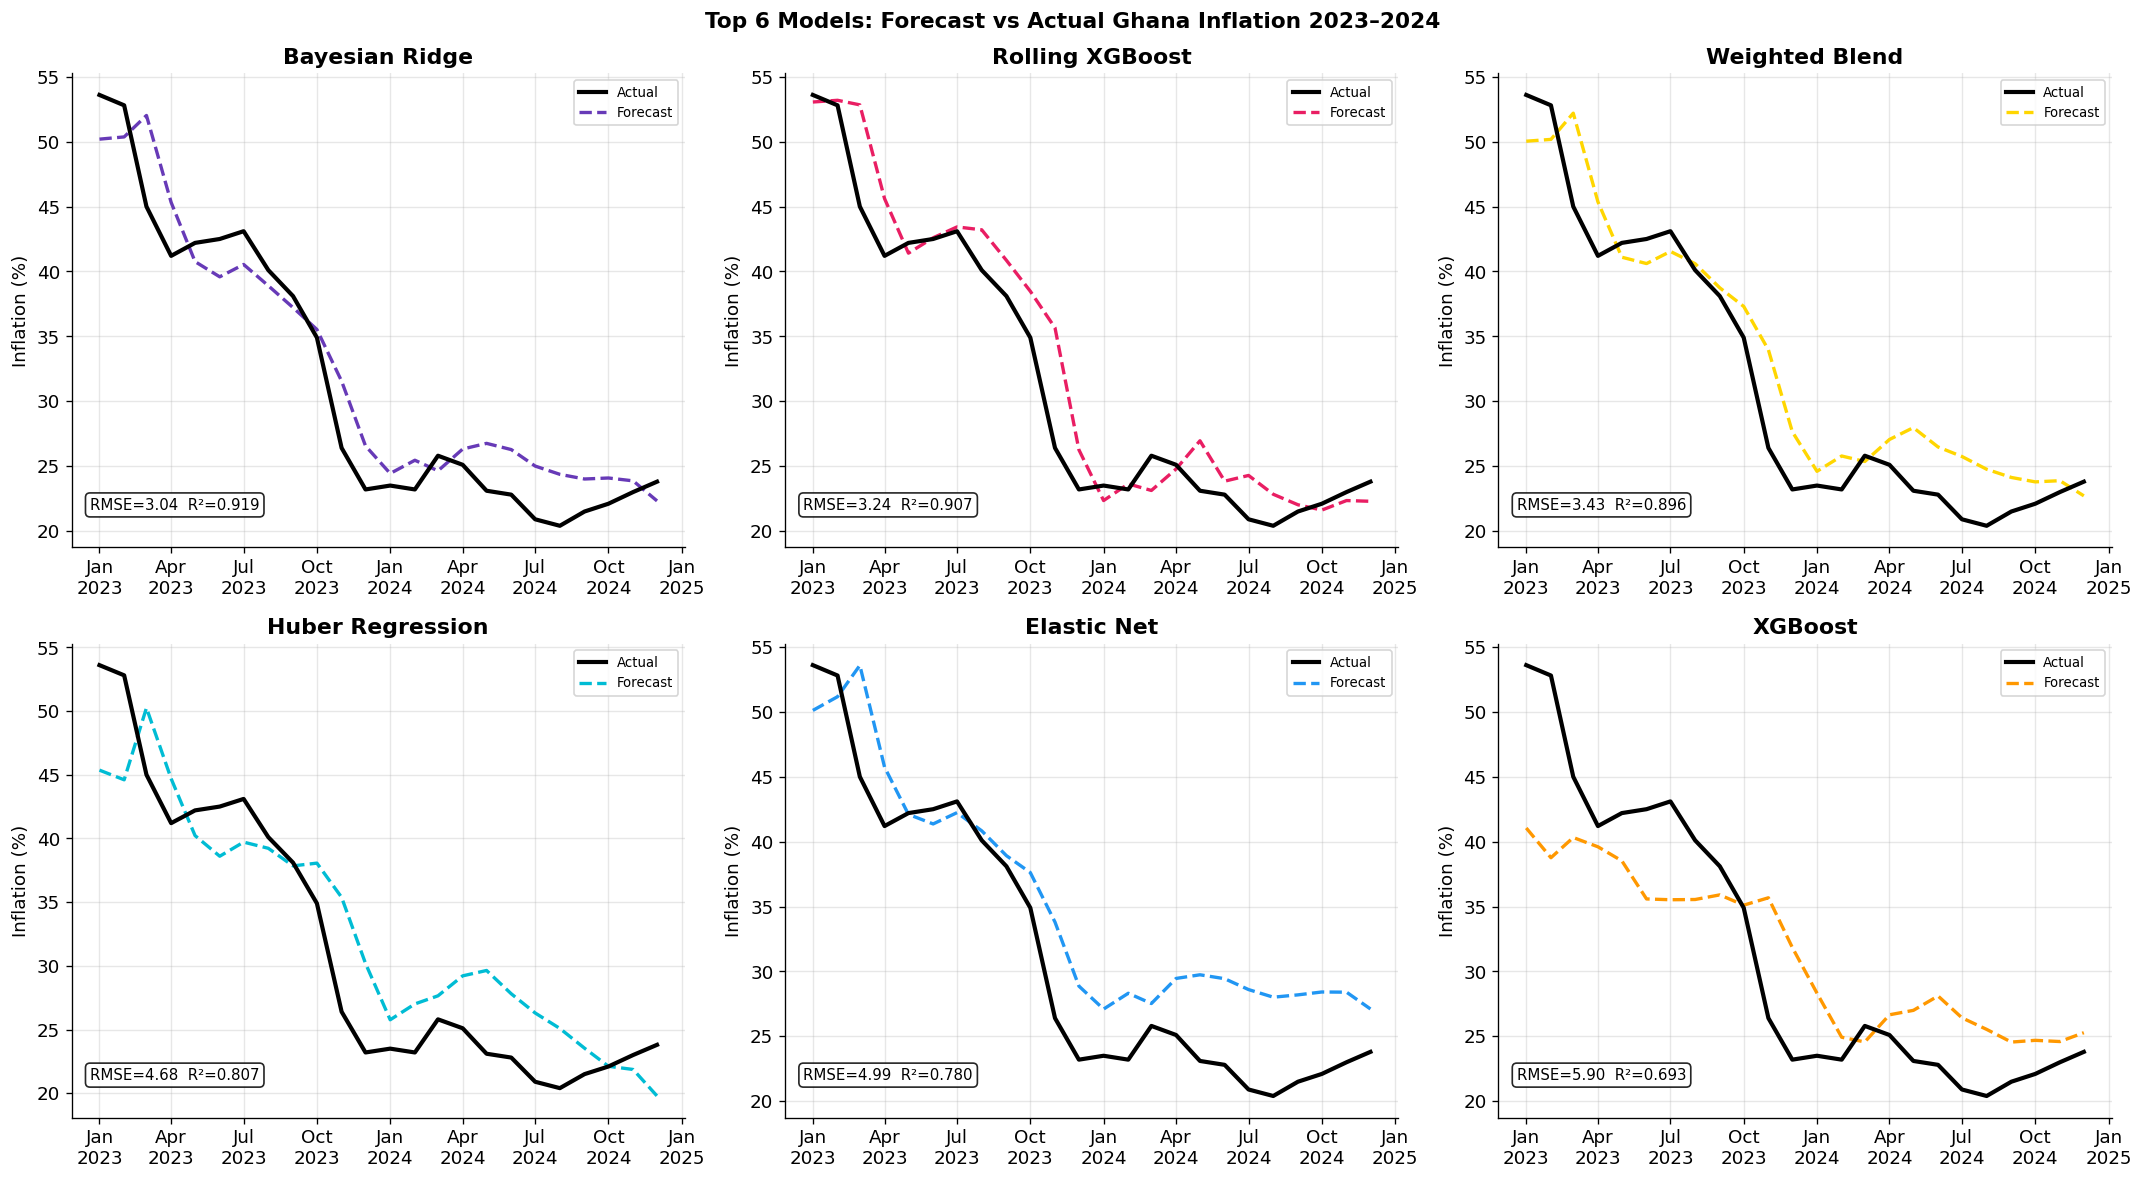

In [22]:
top6 = list(results_df['Model'].head(6))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 6 Models: Forecast vs Actual Ghana Inflation 2023–2024',
             fontsize=13, fontweight='bold')
for ax, name in zip(axes.flat, top6):
    pred = all_preds[name]
    y_t  = yte.iloc[:len(pred)]
    rmse = np.sqrt(mean_squared_error(y_t, pred))
    r2   = r2_score(y_t, pred)
    ax.plot(y_t.index, y_t.values, 'k-', lw=2.5, label='Actual', zorder=5)
    ax.plot(y_t.index, pred, color=COLORS.get(name,'#333'), lw=2, ls='--', label='Forecast')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylabel('Inflation (%)')
    ax.text(0.03, 0.08, f'RMSE={rmse:.2f}  R²={r2:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.tight_layout()
plt.savefig('figures/02_top_forecasts.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. SHAP feature importance

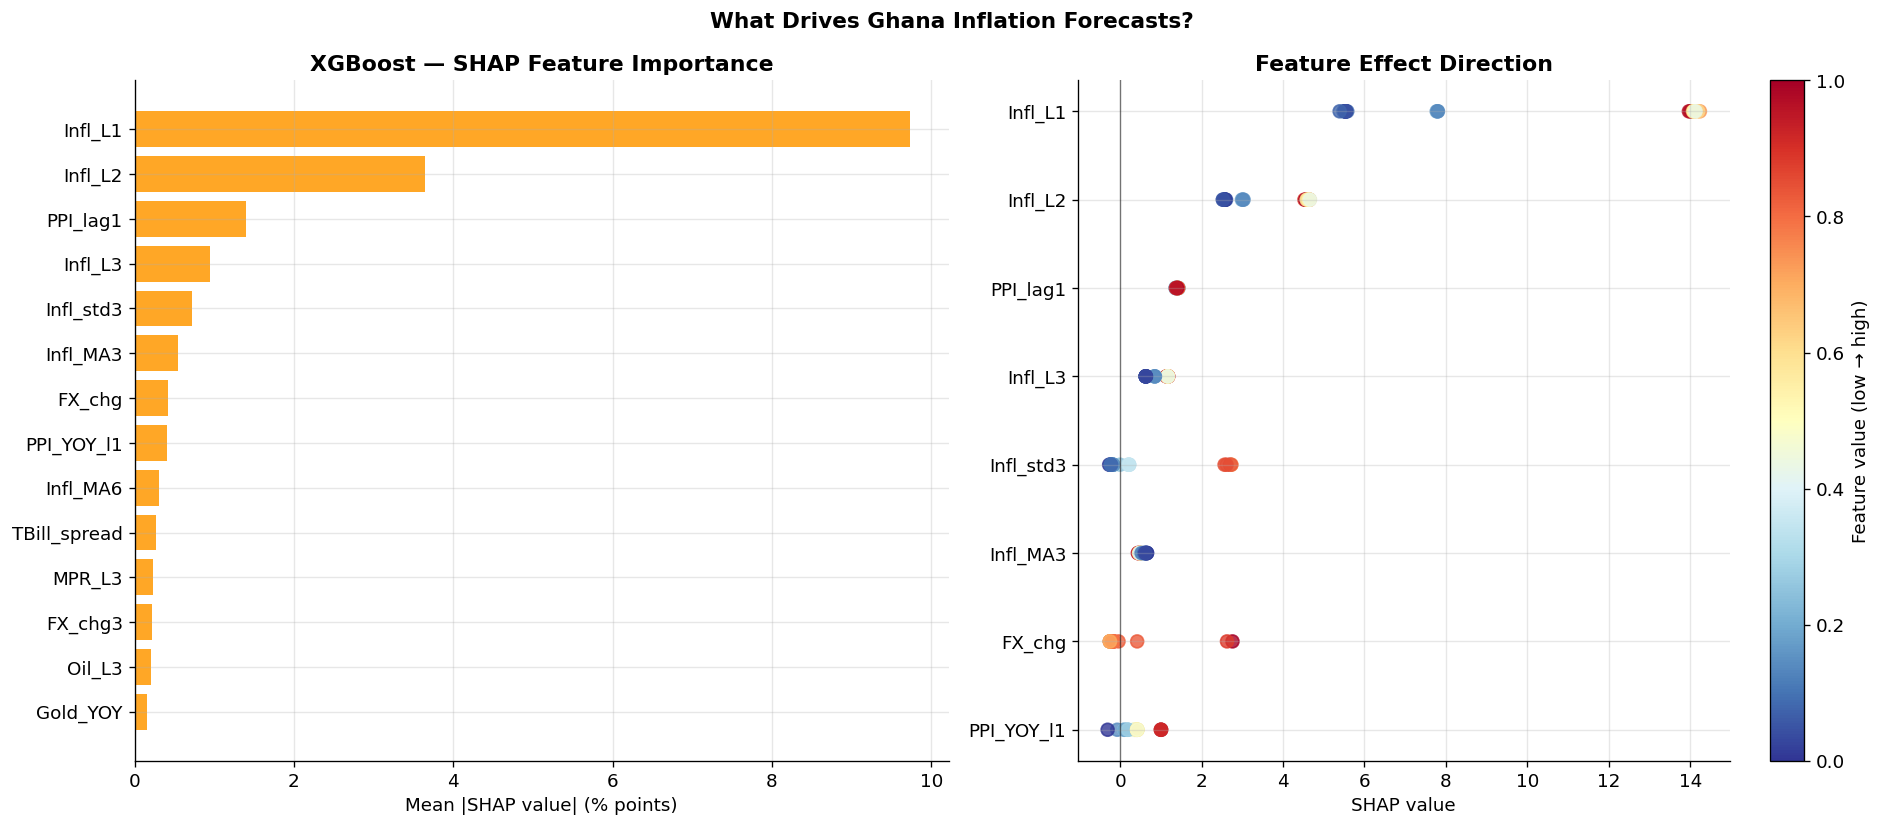

In [23]:
explainer = shap.TreeExplainer(xgb_m)
shap_vals = explainer.shap_values(Xte)
importance = pd.Series(np.abs(shap_vals).mean(0), index=FEATS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(importance.index[:14][::-1], importance.values[:14][::-1], color='#FF9800', alpha=0.85)
axes[0].set_title('XGBoost — SHAP Feature Importance', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value| (% points)')

top8 = importance.index[:8].tolist()
for i, feat in enumerate(top8[::-1]):
    feat_vals = Xte[feat].values
    sv_feat   = shap_vals[:, FEATS.index(feat)]
    feat_norm = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    axes[1].scatter(sv_feat, [i]*len(sv_feat), c=plt.cm.RdYlBu_r(feat_norm), s=60, alpha=0.8)
axes[1].set_yticks(range(len(top8))); axes[1].set_yticklabels(top8[::-1])
axes[1].axvline(0, color='black', lw=0.8, alpha=0.5)
axes[1].set_xlabel('SHAP value'); axes[1].set_title('Feature Effect Direction', fontweight='bold')
sm_cb = plt.cm.ScalarMappable(cmap='RdYlBu_r'); sm_cb.set_array([])
plt.colorbar(sm_cb, ax=axes[1], label='Feature value (low → high)')
fig.suptitle('What Drives Ghana Inflation Forecasts?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_shap.png', bbox_inches='tight', dpi=150)
plt.show()

## 14. Bootstrap prediction intervals

90% CI empirical coverage: 88%  (target = 90%)


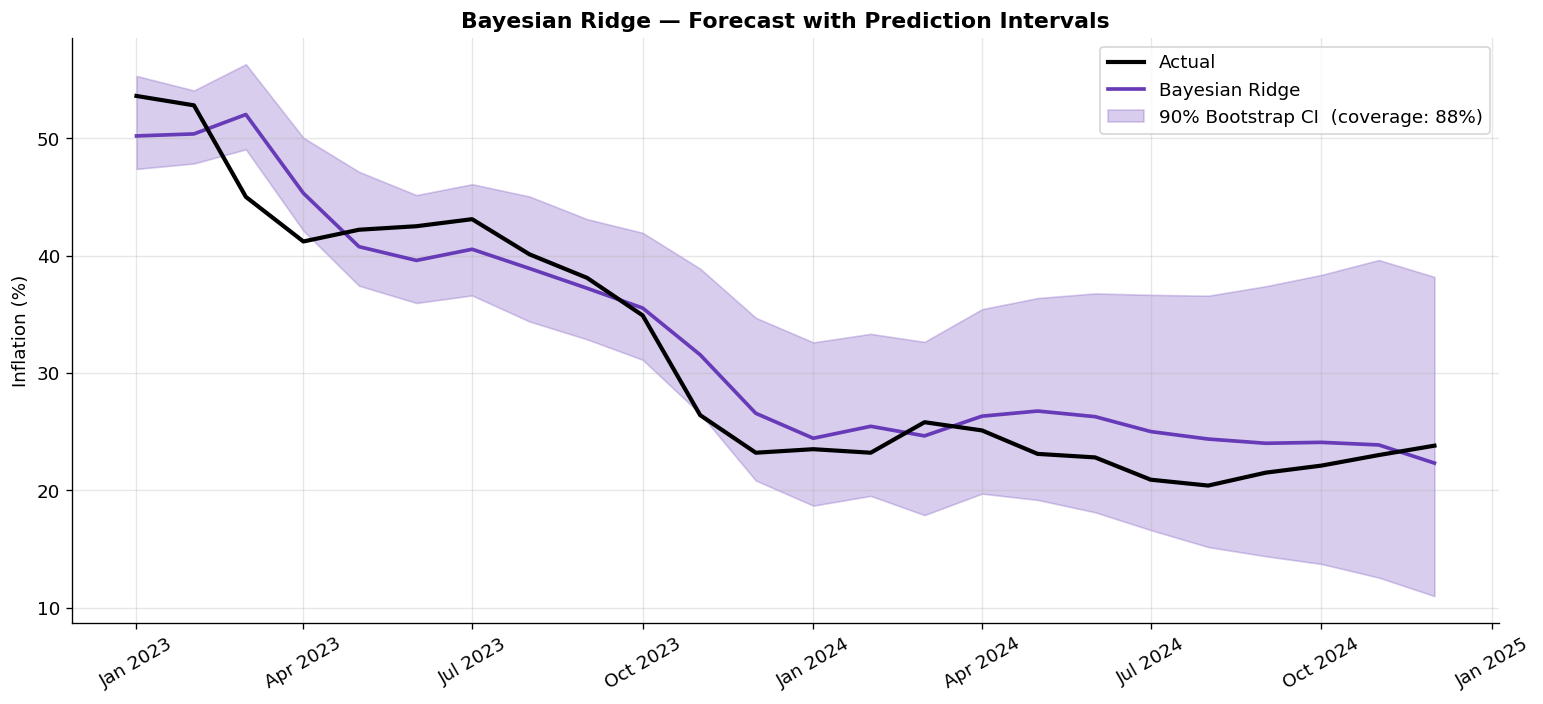

In [24]:
np.random.seed(42)
N_BOOT = 300
boot_preds = np.zeros((N_BOOT, len(Xte)))
for b in range(N_BOOT):
    idx  = np.random.choice(len(Xtr_s), len(Xtr_s), replace=True)
    sc_b = StandardScaler()
    Xb   = sc_b.fit_transform(Xtr_s[idx])       # fit on bootstrap sample
    Xf   = sc_b.transform(Xte_s)
    m    = BayesianRidge(max_iter=300).fit(Xb, ytr.values[idx])
    boot_preds[b] = m.predict(Xf)

lo, hi = np.percentile(boot_preds, 5, axis=0), np.percentile(boot_preds, 95, axis=0)
coverage = np.mean((yte.values >= lo) & (yte.values <= hi))
print(f"90% CI empirical coverage: {coverage:.0%}  (target = 90%)")

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(yte.index, yte.values, 'k-', lw=2.5, label='Actual', zorder=5)
ax.plot(yte.index, all_preds['Bayesian Ridge'], '#673AB7', lw=2.2, label='Bayesian Ridge')
ax.fill_between(yte.index, lo, hi, alpha=0.25, color='#673AB7',
                label=f'90% Bootstrap CI  (coverage: {coverage:.0%})')
ax.set_title('Bayesian Ridge — Forecast with Prediction Intervals', fontweight='bold')
ax.set_ylabel('Inflation (%)'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('figures/05_pred_intervals.png', bbox_inches='tight', dpi=150)
plt.show()